# Лабораторная работа №7. Импульсные нейронные сети## Дисциплина: Искусственный интеллект### Автор: Мыльников Александр Русланович, группа ФИТ-221### Дата: 2026-05-01### Тема диплома: Обнаружение дефектных изделий на производственной линии с использованием алгоритмов компьютерного зрения

## 1. Настройка окружения и импорт модулей

In [5]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import torch, torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import snntorch as snn

from src.snn.lif_neuron import LIFNeuron
from src.snn.snn_classifier import SNNClassifier, SNNTrainer
from src.snn.comparison import SNNvsANNComparator
from src.snn.defect_detection_snn import DefectDetectionSNN

%matplotlib inline
print('All modules loaded')

All modules loaded


## 2. Демонстрация LIF-нейрона

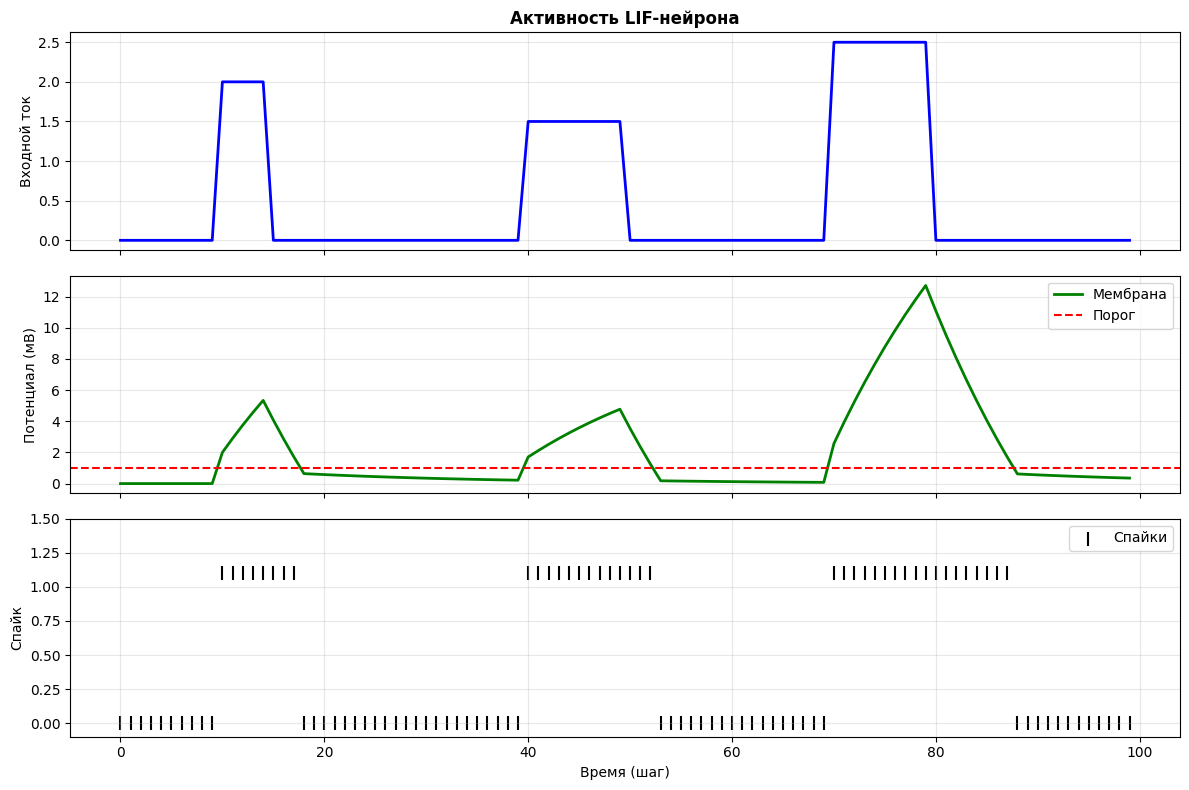

Total spikes: 39
Spike rate: 39.0%


In [6]:
neuron = LIFNeuron(beta=0.95, threshold=1.0)
num_steps = 100
I = torch.zeros(num_steps)
I[10:15] = 2.0
I[40:50] = 1.5
I[70:80] = 2.5

spikes, mem = neuron.simulate(I)
fig = neuron.visualize(I, spikes, mem)
plt.show()

print(f'Total spikes: {spikes.sum().item():.0f}')
print(f'Spike rate: {spikes.mean().item()*100:.1f}%')

## 3. Обучение SNN-классификатора (1 эпоха)

In [7]:
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
train_dataset = datasets.MNIST(root='../data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

model = SNNClassifier(num_inputs=784, num_hidden=100, num_outputs=10, beta=0.95)
trainer = SNNTrainer(model, learning_rate=1e-3, device='cpu')

avg_loss, accuracy = trainer.train_epoch(train_loader, num_steps=25)
print(f'Loss: {avg_loss:.4f}, Accuracy: {accuracy*100:.2f}%')

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9912422/9912422 [01:54<00:00, 86738.19it/s] 


Extracting ../data\MNIST\raw\train-images-idx3-ubyte.gz to ../data\MNIST\raw

Using downloaded and verified file: ../data\MNIST\raw\train-labels-idx1-ubyte.gz
Extracting ../data\MNIST\raw\train-labels-idx1-ubyte.gz to ../data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1648877/1648877 [00:12<00:00, 132891.20it/s]


Extracting ../data\MNIST\raw\t10k-images-idx3-ubyte.gz to ../data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4542/4542 [00:00<00:00, 560804.50it/s]


Extracting ../data\MNIST\raw\t10k-labels-idx1-ubyte.gz to ../data\MNIST\raw



Обучение: 100%|██████████| 938/938 [01:57<00:00,  8.00it/s, loss=0.0374, acc=0.6015]

Loss: 0.0626, Accuracy: 60.15%


## 4. Сравнение SNN vs ANN

In [13]:
test_dataset = datasets.MNIST(root='../data', train=False, download=True, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=100, shuffle=False)
test_data, test_targets = next(iter(test_loader))

comparator = SNNvsANNComparator(num_inputs=784, num_hidden=100, num_outputs=10, beta=0.95)
ann_res, snn_res = comparator.compare(test_data, test_targets)
comparator.print_comparison(ann_res, snn_res)


СРАВНЕНИЕ SNN vs ANN

Метрика                        ANN                  SNN                  Улучшение      
--------------------------------------------------------------------------------
Точность                       0.1400               0.0700               -7.00%         
Время инференса (мс)           1.70                 39.30                0.0x           
Энергопотребление (мДж)        84.8365              1.9649               43x            
Параметры                      89,610               89,610               1.0x           
Спайки                         N/A                  283.0                —              

ВЫВОДЫ:
  • SNN обеспечивают значительную экономию энергии (100-1000x)
  • Точность SNN может быть немного ниже (1-5%)
  • SNN идеальны для edge-устройств с ограниченным питанием
  • ANN лучше для задач с максимальной точностью


## 5. Адаптация под специальность (обнаружение дефектов)

In [14]:
defect_model = DefectDetectionSNN(input_channels=1, input_height=64, input_width=64,
                                  num_classes=2, hidden_features=128, beta=0.95)

test_images = torch.randn(4, 1, 64, 64)
predictions = defect_model.predict(test_images)
probs = defect_model.predict_defect_probability(test_images)

print('Predicted classes:', predictions)
print('Defect probabilities:')
print(probs)

Predicted classes: tensor([0, 0, 0, 0])
Defect probabilities:
tensor([[0.0400, 0.0000],
        [0.0000, 0.0000],
        [0.0000, 0.0000],
        [0.0000, 0.0000]])


## 6. Визуализация спайков по слоям

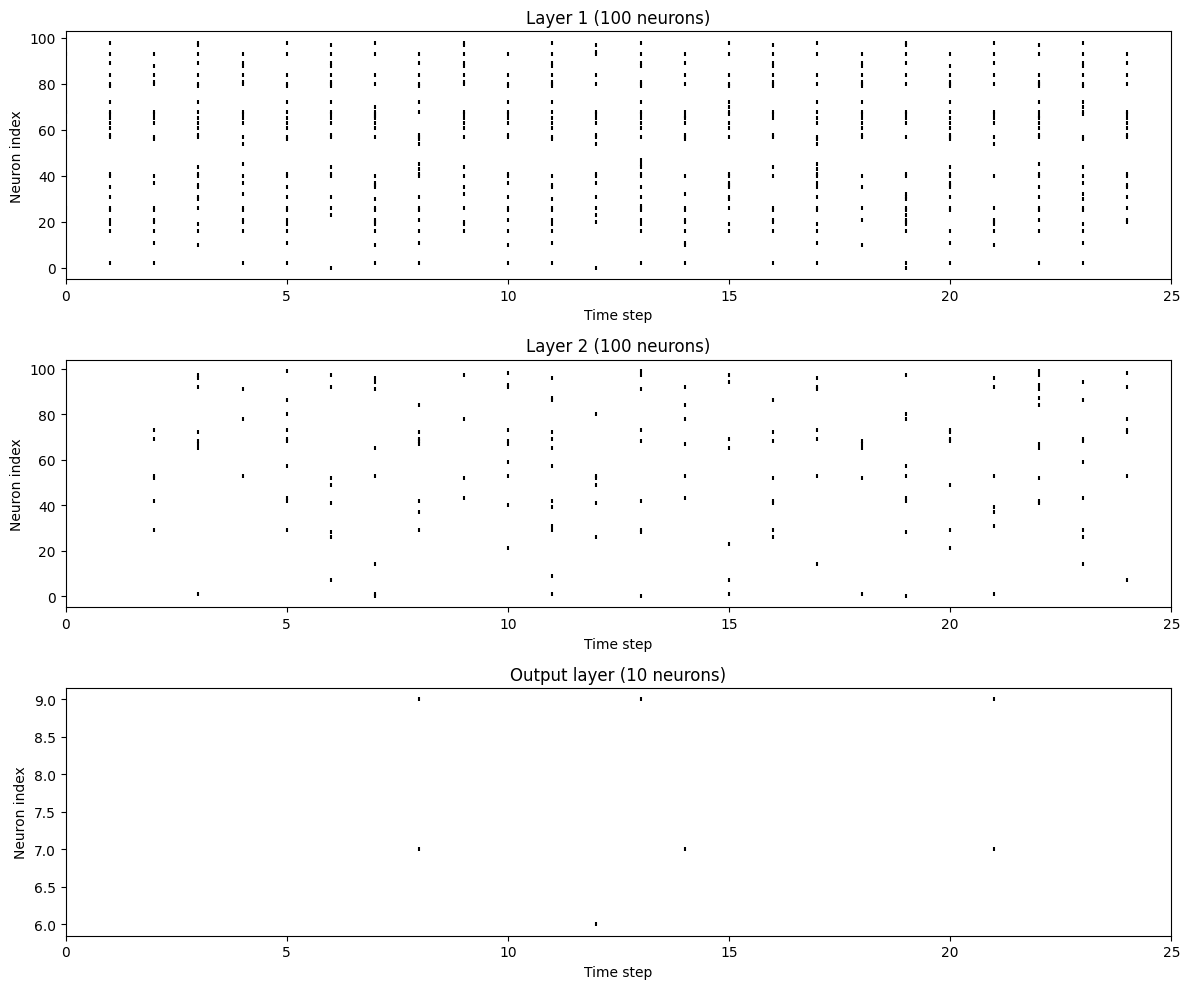

Raster plot saved to layer_spikes.png


In [16]:
import numpy as np
def plot_layer_spikes(spike_tensor, title, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 4))
    time_steps, batch, neurons = spike_tensor.shape
    for n in range(neurons):
        spikes_n = spike_tensor[:, :, n].cpu().numpy()
        times, batch_ids = np.where(spikes_n)
        ax.scatter(times, batch_ids * neurons + n, s=10, c='black', marker='|')
    ax.set_xlabel('Time step')
    ax.set_ylabel('Neuron index')
    ax.set_title(title)
    ax.set_xlim(0, time_steps)
    return ax

# Получим спайки слоёв для одного изображения
img, _ = test_dataset[0]
img_batch = img.unsqueeze(0)
snn_model = SNNClassifier(num_inputs=784, num_hidden=100, num_outputs=10, beta=0.95)

# Соберём спайки прямо в ячейке (без изменения класса)
snn_model.eval()
with torch.no_grad():
    x = img_batch.view(1, -1)
    snn_model.lif1.reset_mem()
    snn_model.lif2.reset_mem()
    snn_model.lif3.reset_mem()
    spk1_list, spk2_list, spk3_list = [], [], []
    for step in range(25):
        cur1 = snn_model.fc1(x)
        spk1, _ = snn_model.lif1(cur1)
        cur2 = snn_model.fc2(spk1)
        spk2, _ = snn_model.lif2(cur2)
        cur3 = snn_model.fc3(spk2)
        spk3, _ = snn_model.lif3(cur3)
        spk1_list.append(spk1)
        spk2_list.append(spk2)
        spk3_list.append(spk3)
    spk1_t = torch.stack(spk1_list)  # [25, 1, 100]
    spk2_t = torch.stack(spk2_list)  # [25, 1, 100]
    spk3_t = torch.stack(spk3_list)  # [25, 1, 10]

fig, axes = plt.subplots(3, 1, figsize=(12, 10))
plot_layer_spikes(spk1_t, 'Layer 1 (100 neurons)', ax=axes[0])
plot_layer_spikes(spk2_t, 'Layer 2 (100 neurons)', ax=axes[1])
plot_layer_spikes(spk3_t, 'Output layer (10 neurons)', ax=axes[2])
plt.tight_layout()
plt.savefig('../docs/layer_spikes.png', dpi=150)
plt.show()
print('Raster plot saved to layer_spikes.png')